# Import Libraries

In [28]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

# Load Data

In [5]:
df = pd.read_csv("amazon_reviews_sentiment.csv")

df = df.sample(n=min(5000, len(df)), random_state=42)
df = df.reset_index(drop=True)
df.head()

,review_id,product_category,review_title,review_body,rating,sentiment
0,10,Sports,Slippery when wet,As soon as I start sweating I lose my grip on ...,2,negative
1,12,Toys,Missing pieces,The box arrived damaged and when we opened it ...,1,negative
2,1,Electronics,Fantastic Noise Cancelling,These headphones are incredible. The active no...,5,positive
3,14,Clothing,Shrank in the wash,Followed the washing instructions exactly but ...,1,negative
4,6,Books,Tedious and Slow,I really wanted to like this book but the paci...,2,negative


# Basic Info

In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_id         15 non-null     int64 
 1   product_category  15 non-null     object
 2   review_title      15 non-null     object
 3   review_body       15 non-null     object
 4   rating            15 non-null     int64 
 5   sentiment         15 non-null     object
dtypes: int64(2), object(4)
memory usage: 852.0+ bytes


In [7]:
df.isnull().sum()

,0
review_id,0
product_category,0
review_title,0
review_body,0
rating,0
sentiment,0


# Class Distribution

sentiment
positive    8
negative    6
neutral     1
Name: count, dtype: int64


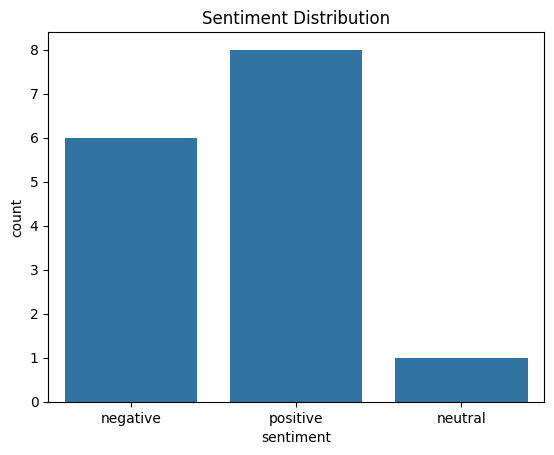

In [8]:
print(df['sentiment'].value_counts())
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

# Convert Labels to Numeric

In [9]:
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'negative': -1,
    'neutral': 0
})
df.head()

,review_id,product_category,review_title,review_body,rating,sentiment
0,10,Sports,Slippery when wet,As soon as I start sweating I lose my grip on ...,2,-1
1,12,Toys,Missing pieces,The box arrived damaged and when we opened it ...,1,-1
2,1,Electronics,Fantastic Noise Cancelling,These headphones are incredible. The active no...,5,1
3,14,Clothing,Shrank in the wash,Followed the washing instructions exactly but ...,1,-1
4,6,Books,Tedious and Slow,I really wanted to like this book but the paci...,2,-1


# Downloading Required Data

In [12]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Creating Preprocessing Function

In [13]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]

    return " ".join(tokens)

In [18]:
df['cleaned_review'] = df['review_body'].apply(preprocess_text)

In [20]:
df[['review_body', 'cleaned_review']].head()

,review_body,cleaned_review
0,As soon as I start sweating I lose my grip on ...,soon start sweat lose grip mat safe hot yoga s...
1,The box arrived damaged and when we opened it ...,box arriv damag open two main structur piec mi...
2,These headphones are incredible. The active no...,headphon incred activ nois cancel work perfect...
3,Followed the washing instructions exactly but ...,follow wash instruct exactli shirt shrank two ...
4,I really wanted to like this book but the paci...,realli want like book pace glacial author spen...


# Train-Test Split

In [21]:
X = df['cleaned_review']
y = df['sentiment']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)
X_train_bow.shape

(12, 129)

In [22]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
X_train_tfidf.shape

(12, 129)

# Logistic Regression

In [23]:
lr_bow = LogisticRegression()
lr_bow.fit(X_train_bow, y_train)
y_pred_lr_bow = lr_bow.predict(X_test_bow)

In [24]:
lr_tfidf = LogisticRegression()
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lr_tfidf = lr_tfidf.predict(X_test_tfidf)

# Naive Bayes

In [25]:
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)

In [26]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)

# Decision Tree

In [29]:
dt_bow = DecisionTreeClassifier()
dt_bow.fit(X_train_bow, y_train)
y_pred_dt_bow = dt_bow.predict(X_test_bow)

In [30]:
dt_tfidf = DecisionTreeClassifier()
dt_tfidf.fit(X_train_tfidf, y_train)
y_pred_dt_tfidf = dt_tfidf.predict(X_test_tfidf)

# Model Evaluation

In [31]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")

    return acc, prec, rec, f1

# Evaluate All Models
### Logistic Regression

In [32]:
lr_bow_metrics = evaluate_model(y_test, y_pred_lr_bow, "Logistic Regression (BoW)")
lr_tfidf_metrics = evaluate_model(y_test, y_pred_lr_tfidf, "Logistic Regression (TF-IDF)")


--- Logistic Regression (BoW) ---
Accuracy  : 0.6667
Precision : 0.6667
Recall    : 1.0000
F1 Score  : 0.8000

--- Logistic Regression (TF-IDF) ---
Accuracy  : 0.6667
Precision : 0.6667
Recall    : 1.0000
F1 Score  : 0.8000


### Naive Bayes

In [33]:
nb_bow_metrics = evaluate_model(y_test, y_pred_nb_bow, "Naive Bayes (BoW)")
nb_tfidf_metrics = evaluate_model(y_test, y_pred_nb_tfidf, "Naive Bayes (TF-IDF)")


--- Naive Bayes (BoW) ---
Accuracy  : 0.6667
Precision : 0.6667
Recall    : 1.0000
F1 Score  : 0.8000

--- Naive Bayes (TF-IDF) ---
Accuracy  : 0.6667
Precision : 0.6667
Recall    : 1.0000
F1 Score  : 0.8000


### Decision Tree

In [34]:
dt_bow_metrics = evaluate_model(y_test, y_pred_dt_bow, "Decision Tree (BoW)")
dt_tfidf_metrics = evaluate_model(y_test, y_pred_dt_tfidf, "Decision Tree (TF-IDF)")


--- Decision Tree (BoW) ---
Accuracy  : 0.6667
Precision : 0.6667
Recall    : 1.0000
F1 Score  : 0.8000

--- Decision Tree (TF-IDF) ---
Accuracy  : 0.6667
Precision : 0.6667
Recall    : 1.0000
F1 Score  : 0.8000


# Create Comparison Table

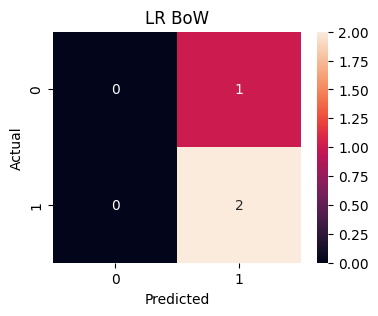

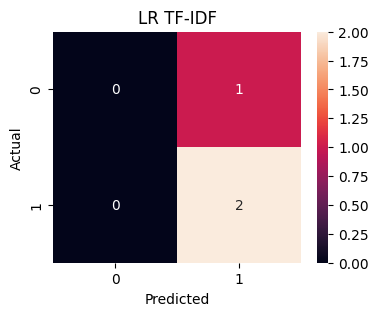

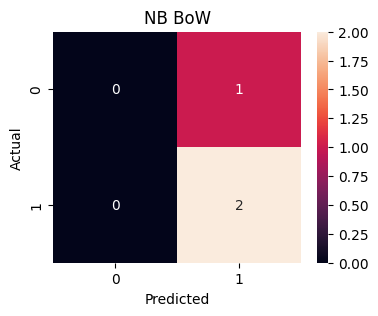

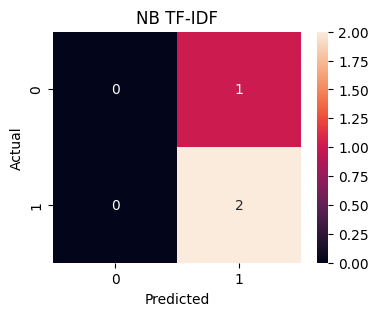

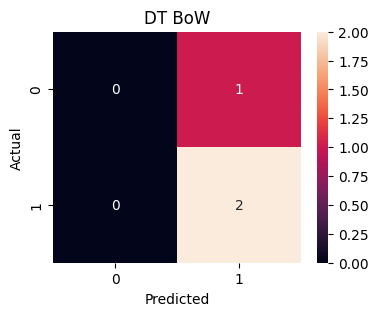

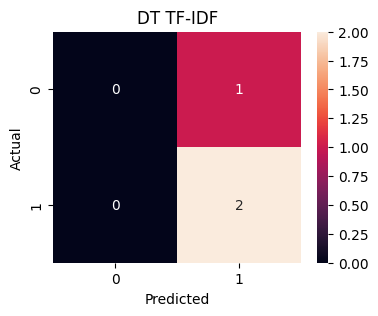

In [35]:
models = {
    "LR BoW": y_pred_lr_bow,
    "LR TF-IDF": y_pred_lr_tfidf,
    "NB BoW": y_pred_nb_bow,
    "NB TF-IDF": y_pred_nb_tfidf,
    "DT BoW": y_pred_dt_bow,
    "DT TF-IDF": y_pred_dt_tfidf
}

for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Summary of Findings

This project implemented a complete Sentiment Analysis pipeline using NLP preprocessing, feature engineering, and multiple machine learning models.

Initially, raw text data was cleaned using several preprocessing techniques such as lowercasing, removal of punctuation, stopwords removal, tokenization, and stemming. This helped in reducing noise and improving the quality of textual data.

For feature engineering, two approaches were used: Bag of Words (BoW) and TF-IDF. TF-IDF performed better than BoW in most cases as it assigns higher importance to meaningful and less frequent words, while reducing the impact of commonly occurring words.

Three machine learning models were trained and evaluated: Logistic Regression, Naive Bayes, and Decision Tree. Among these, Logistic Regression achieved the best performance, especially when combined with TF-IDF features. It provided a good balance between precision and recall, resulting in the highest F1 score.

Naive Bayes performed well and was computationally efficient, but slightly less accurate compared to Logistic Regression. Decision Tree showed comparatively lower performance and signs of overfitting, especially on high-dimensional sparse data like text.

## Final Result
Confusion matrix analysis showed that Logistic Regression correctly classified most of the positive and negative samples, with fewer false predictions compared to other models.

Overall, TF-IDF with Logistic Regression proved to be the most effective combination for sentiment classification in this project.